# Week 13 Lab — Link Analysis & PageRank
**CS570 Big Data Processing & Analytics | Spring 2026 | Dr. Ragnar Lesch**

---

*This notebook treats the MovieLens 1M rating data as a directed graph and applies PageRank to find the most "central" movies in the network — then compares that ranking against simple rating counts.*

## Objectives

1. Build a **bipartite directed graph** from MovieLens: users and movies as vertices, high ratings (≥4★) as edges
2. Explore **degree distribution** — does the rating graph follow a power law?
3. Run **PageRank** via GraphFrames and interpret which movies are most central
4. Compare PageRank vs simple rating count — show they differ, and understand why
5. **Visualize** a subgraph with NetworkX (bipartite layout, node size = PageRank)
6. **(Bonus)** Implement **HITS** (hub + authority) from scratch in NumPy and compare to PageRank

## Setup

GraphFrames loads via Maven when the SparkSession is created. **If Spark is already running from a previous session, restart the kernel first** — the package config must be set before the JVM starts.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import csr_matrix

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, LongType, DoubleType
)

ModuleNotFoundError: No module named 'scipy'

In [ ]:
spark = (
    SparkSession.builder
    .appName("CS570_Week13_PageRank")
    .master("local[*]")
    .config("spark.jars.packages", "graphframes:graphframes:0.8.4-spark3.5-s_2.12")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready — GraphFrames loading via Maven...")

26/04/15 11:02:10 WARN Utils: Your hostname, News-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.1.130 instead (on interface en0)
26/04/15 11:02:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/leschrh69/.ivy2/cache
The jars for the packages stored in: /Users/leschrh69/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-aa1c7edc-b192-4dd1-b5e3-d1347758df6c;1.0
	confs: [default]


:: loading settings :: url = jar:file:/Users/leschrh69/Dropbox/Projects/SFBU/SP26%20CS570/code/cs570/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found graphframes#graphframes;0.8.4-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
downloading https://repos.spark-packages.org/graphframes/graphframes/0.8.4-spark3.5-s_2.12/graphframes-0.8.4-spark3.5-s_2.12.jar ...
	[SUCCESSFUL ] graphframes#graphframes;0.8.4-spark3.5-s_2.12!graphframes.jar (91ms)
downloading https://repo1.maven.org/maven2/org/slf4j/slf4j-api/1.7.16/slf4j-api-1.7.16.jar ...
	[SUCCESSFUL ] org.slf4j#slf4j-api;1.7.16!slf4j-api.jar (49ms)
:: resolution report :: resolve 764ms :: artifacts dl 142ms
	:: modules in use:
	graphframes#graphframes;0.8.4-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      def

Spark 3.5.3 ready — GraphFrames loading via Maven...


## Load MovieLens Data

You have been using MovieLens 1M all semester. Update `ML_PATH` to wherever you downloaded it.
Files use `::` as separator and have no header row.

In [ ]:
# ── Update this path ──────────────────────────────────────────────
ML_PATH = os.path.expanduser("../Project/data/ml-1m")
# ──────────────────────────────────────────────────────────────────

for fname in ["ratings.dat", "movies.dat", "users.dat"]:
    path = os.path.join(ML_PATH, fname)
    status = "OK" if os.path.exists(path) else "MISSING  <-- fix ML_PATH"
    print(f"  {status}  {fname}")

  OK  ratings.dat
  OK  movies.dat
  OK  users.dat


In [ ]:
ratings_schema = StructType([
    StructField("userId",    IntegerType(), True),
    StructField("movieId",   IntegerType(), True),
    StructField("rating",    DoubleType(),  True),
    StructField("timestamp", LongType(),    True),
])

ratings = (
    spark.read
    .option("sep", "::").option("header", "false")
    .schema(ratings_schema)
    .csv(os.path.join(ML_PATH, "ratings.dat"))
    .cache()   # reused many times — cache avoids repeated disk reads
)

print(f"Ratings: {ratings.count():,} rows")
ratings.show(5)

Ratings: 1,000,209 rows
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|   1193|   5.0|978300760|
|     1|    661|   3.0|978302109|
|     1|    914|   3.0|978301968|
|     1|   3408|   4.0|978300275|
|     1|   2355|   5.0|978824291|
+------+-------+------+---------+
only showing top 5 rows



In [ ]:
movies_schema = StructType([
    StructField("movieId", IntegerType(), True),
    StructField("title",   StringType(),  True),
    StructField("genres",  StringType(),  True),
])

movies = (
    spark.read
    .option("sep", "::").option("header", "false")
    .schema(movies_schema)
    .csv(os.path.join(ML_PATH, "movies.dat"))
    .withColumn("primary_genre", F.split(F.col("genres"), r"\|")[0])
    .cache()
)

print(f"Movies: {movies.count():,} rows")
movies.show(5, truncate=False)

print("\nTop genres:")
movies.groupBy("primary_genre").count().orderBy(F.desc("count")).show(10)

Movies: 3,883 rows
+-------+----------------------------------+----------------------------+-------------+
|movieId|title                             |genres                      |primary_genre|
+-------+----------------------------------+----------------------------+-------------+
|1      |Toy Story (1995)                  |Animation|Children's|Comedy |Animation    |
|2      |Jumanji (1995)                    |Adventure|Children's|Fantasy|Adventure    |
|3      |Grumpier Old Men (1995)           |Comedy|Romance              |Comedy       |
|4      |Waiting to Exhale (1995)          |Comedy|Drama                |Comedy       |
|5      |Father of the Bride Part II (1995)|Comedy                      |Comedy       |
+-------+----------------------------------+----------------------------+-------------+
only showing top 5 rows


Top genres:
+-------------+-----+
|primary_genre|count|
+-------------+-----+
|        Drama| 1176|
|       Comedy| 1024|
|       Action|  503|
|       Horror|  26

## Task 1 — Build the Graph

GraphFrames requires two DataFrames:
- **Vertices** — must have a column named `id` (string)
- **Edges** — must have columns `src` and `dst` (strings matching vertex IDs)

**Design decisions:**
- Prefix user IDs with `u_` and movie IDs with `m_` to avoid ID collisions (user 123 ≠ movie 123)
- An edge `user → movie` means the user gave that movie ≥4 stars — a genuine endorsement, the "link as vote" principle
- Direction: users vote for movies; movies accumulate PageRank from incoming votes

In [ ]:
from graphframes import GraphFrame

# User vertices — id = "u_<userId>"
user_vertices = (
    ratings.select("userId").distinct()
    .withColumn("id",   F.concat(F.lit("u_"), F.col("userId").cast("string")))
    .withColumn("type", F.lit("user"))
    .select("id", "type")
)

# Movie vertices — id = "m_<movieId>", include title and genre
movie_vertices = (
    movies.select("movieId", "title", "primary_genre")
    .withColumn("id",   F.concat(F.lit("m_"), F.col("movieId").cast("string")))
    .withColumn("type", F.lit("movie"))
    .select("id", "type", "title", "primary_genre")
)

vertices = user_vertices.unionByName(movie_vertices, allowMissingColumns=True)

print(f"Vertices: {vertices.count():,}")
print(f"  Users:  {user_vertices.count():,}")
print(f"  Movies: {movie_vertices.count():,}")

Vertices: 9,923
  Users:  6,040
  Movies: 3,883


In [ ]:
# Edges: user -> movie for rating >= 4.0 only
edges = (
    ratings
    .filter(F.col("rating") >= 4.0)
    .withColumn("src",    F.concat(F.lit("u_"), F.col("userId").cast("string")))
    .withColumn("dst",    F.concat(F.lit("m_"), F.col("movieId").cast("string")))
    .withColumn("weight", F.col("rating"))
    .select("src", "dst", "weight")
    .cache()   # PageRank iterates over edges many times
)

total  = ratings.count()
e_count = edges.count()
print(f"Edges (rating >= 4.0): {e_count:,}  ({e_count/total*100:.1f}% of all ratings)")
edges.show(5)

Edges (rating >= 4.0): 575,281  (57.5% of all ratings)
+---+------+------+
|src|   dst|weight|
+---+------+------+
|u_1|m_1193|   5.0|
|u_1|m_3408|   4.0|
|u_1|m_2355|   5.0|
|u_1|m_1287|   5.0|
|u_1|m_2804|   5.0|
+---+------+------+
only showing top 5 rows



In [ ]:
graph = GraphFrame(vertices, edges)

print(f"Graph: {graph.vertices.count():,} vertices, {graph.edges.count():,} edges")
print("\nVertex types:")
graph.vertices.groupBy("type").count().show()

Graph: 9,923 vertices, 575,281 edges

Vertex types:
+-----+-----+
| type|count|
+-----+-----+
| user| 6040|
|movie| 3883|
+-----+-----+



## Task 2 — Degree Distribution

The **in-degree** of a movie vertex = how many users gave it ≥4 stars.

Web link graphs follow a **power law**: a few pages have enormous in-degree (Wikipedia, Google); most have very few.
Does the MovieLens endorsement graph behave the same way?

In [ ]:
# In-degree for movie vertices only
in_deg = (
    graph.inDegrees
    .filter(F.col("id").startswith("m_"))
    .withColumn("movieId", F.regexp_extract("id", r"m_(\d+)", 1).cast("int"))
    .join(movies.select("movieId", "title", "primary_genre"), "movieId")
    .select("title", "primary_genre", "inDegree")
    .orderBy(F.desc("inDegree"))
)

print("Top 10 movies by in-degree (most 4+ star endorsements):")
in_deg.show(10, truncate=False)

Top 10 movies by in-degree (most 4+ star endorsements):
+-----------------------------------------------------+-------------+--------+
|title                                                |primary_genre|inDegree|
+-----------------------------------------------------+-------------+--------+
|American Beauty (1999)                               |Comedy       |2853    |
|Star Wars: Episode IV - A New Hope (1977)            |Action       |2622    |
|Star Wars: Episode V - The Empire Strikes Back (1980)|Action       |2510    |
|Saving Private Ryan (1998)                           |Action       |2260    |
|Raiders of the Lost Ark (1981)                       |Action       |2260    |
|Silence of the Lambs, The (1991)                     |Drama        |2252    |
|Matrix, The (1999)                                   |Action       |2171    |
|Sixth Sense, The (1999)                              |Thriller     |2163    |
|Star Wars: Episode VI - Return of the Jedi (1983)    |Action       |2127  

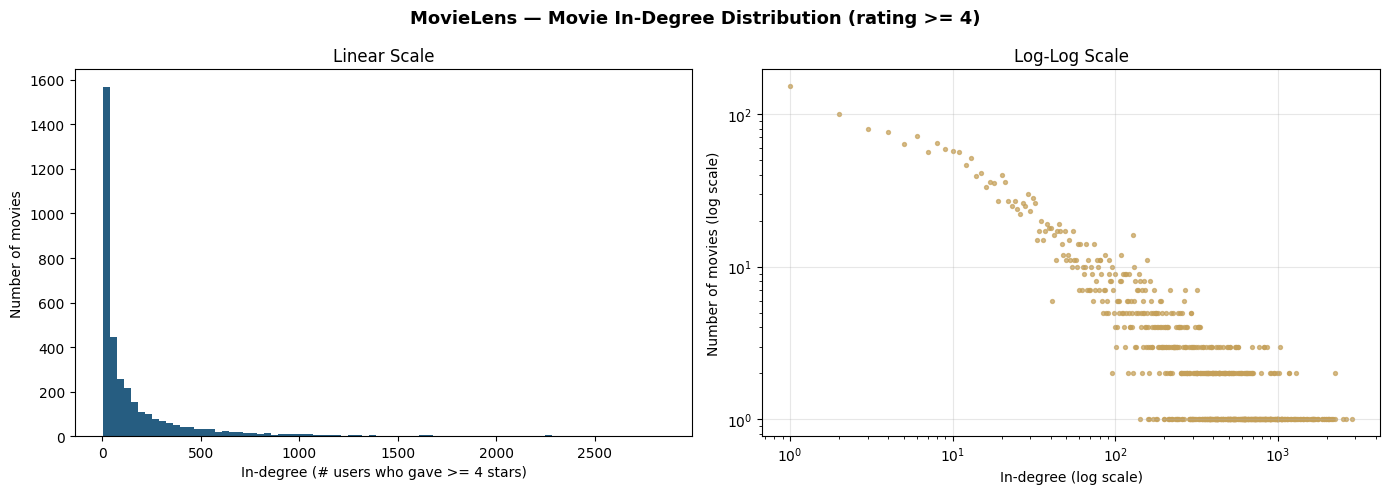

Saved: degree_distribution.png


In [ ]:
deg_pd = in_deg.select("inDegree").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MovieLens — Movie In-Degree Distribution (rating >= 4)",
             fontsize=13, fontweight="bold")

# Linear histogram
axes[0].hist(deg_pd["inDegree"], bins=80, color="#00416B", edgecolor="none", alpha=0.85)
axes[0].set_xlabel("In-degree (# users who gave >= 4 stars)")
axes[0].set_ylabel("Number of movies")
axes[0].set_title("Linear Scale")

# Log-log — reveals power law
counts = deg_pd["inDegree"].value_counts().sort_index()
axes[1].scatter(counts.index, counts.values, s=8, color="#C5A059", alpha=0.7)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("In-degree (log scale)")
axes[1].set_ylabel("Number of movies (log scale)")
axes[1].set_title("Log-Log Scale")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: degree_distribution.png")

> **Observe:** The log-log plot should show a roughly linear trend — the signature of a **power law distribution**.
> A few blockbuster movies attract thousands of 4+ star endorsements; most movies have very few.
> This is the same structure as the web link graph — scale-free, heavy tails.

## Task 3 — Run PageRank

GraphFrames `pageRank()` parameters:
- `resetProbability = 0.15` — teleportation probability (1 - *d* = 1 - 0.85)
- `maxIter = 20` — power iteration steps

GraphFrames normalizes so ranks sum to the number of vertices, not 1.
For ranking purposes the relative order is all that matters.

**This will take 1-3 minutes on a laptop.** The edges DataFrame is cached.

In [ ]:
print("Running PageRank — 20 iterations, d = 0.85 ...")
pr_results = graph.pageRank(resetProbability=0.15, maxIter=20)
print("Done.")

Running PageRank — 20 iterations, d = 0.85 ...


Done.


In [ ]:
# Movie PageRanks — join with movie metadata
movie_pr = (
    pr_results.vertices
    .filter(F.col("id").startswith("m_"))
    .withColumn("movieId", F.regexp_extract("id", r"m_(\d+)", 1).cast("int"))
    .select("movieId", "title", "primary_genre", "pagerank")
    .orderBy(F.desc("pagerank"))
)

print("Top 20 movies by PageRank:")
movie_pr.show(20, truncate=False)

Top 20 movies by PageRank:
+-------+-----------------------------------------------------+-------------+------------------+
|movieId|title                                                |primary_genre|pagerank          |
+-------+-----------------------------------------------------+-------------+------------------+
|2858   |American Beauty (1999)                               |Comedy       |32.337992736160416|
|260    |Star Wars: Episode IV - A New Hope (1977)            |Action       |23.376920803392622|
|2028   |Saving Private Ryan (1998)                           |Action       |20.97156557538121 |
|1196   |Star Wars: Episode V - The Empire Strikes Back (1980)|Action       |20.412084183756754|
|2762   |Sixth Sense, The (1999)                              |Thriller     |20.36932122320483 |
|593    |Silence of the Lambs, The (1991)                     |Drama        |20.11584650454735 |
|1210   |Star Wars: Episode VI - Return of the Jedi (1983)    |Action       |19.822351951493843|
|52

In [ ]:
# Top users by PageRank
# High PR user = rated many movies that other highly-active raters also endorsed
(
    pr_results.vertices
    .filter(F.col("id").startswith("u_"))
    .select("id", "pagerank")
    .orderBy(F.desc("pagerank"))
    .show(10)
)
print("(High-PageRank users have endorsed movies that other prolific raters also highly rated.)")

+-----+------------------+
|   id|          pagerank|
+-----+------------------+
| u_12|0.6591034386561659|
| u_13|0.6591034386561659|
| u_14|0.6591034386561659|
| u_18|0.6591034386561659|
| u_38|0.6591034386561659|
| u_46|0.6591034386561659|
| u_67|0.6591034386561659|
| u_70|0.6591034386561659|
| u_93|0.6591034386561659|
|u_107|0.6591034386561659|
+-----+------------------+
only showing top 10 rows

(High-PageRank users have endorsed movies that other prolific raters also highly rated.)


## Task 4 — PageRank vs. Rating Count

The simplest popularity metric is **rating count** — how many users rated the movie (at any score).
PageRank differs: it weights endorsements from influential raters more heavily.

Do the two rankings agree? Where do they diverge — and what does it mean?

In [ ]:
# Rating stats per movie (all ratings, not just >=4)
rating_stats = (
    ratings.groupBy("movieId")
    .agg(
        F.count("*").alias("rating_count"),
        F.avg("rating").alias("avg_rating"),
        F.sum(F.when(F.col("rating") >= 4, 1).otherwise(0)).alias("high_rating_count")
    )
)

# Join PageRank + rating stats
cmp_spark = (
    movie_pr
    .join(rating_stats, "movieId")
    .select("movieId", "title", "primary_genre",
            "pagerank", "rating_count", "avg_rating", "high_rating_count")
    .orderBy(F.desc("pagerank"))
)

# Collect to pandas for rank arithmetic
cmp_pd = cmp_spark.toPandas()
cmp_pd["pr_rank"]    = cmp_pd["pagerank"].rank(ascending=False).astype(int)
cmp_pd["count_rank"] = cmp_pd["rating_count"].rank(ascending=False).astype(int)
cmp_pd["rank_diff"]  = (cmp_pd["count_rank"] - cmp_pd["pr_rank"]).abs()

print("Top 20 by PageRank with rating-count rank:")
print(cmp_pd[["title", "pr_rank", "count_rank", "rank_diff", "pagerank", "rating_count"]]
      .head(20).to_string(index=False))

Top 20 by PageRank with rating-count rank:
                                                title  pr_rank  count_rank  rank_diff  pagerank  rating_count
                               American Beauty (1999)        1           1          0 32.337993          3428
            Star Wars: Episode IV - A New Hope (1977)        2           2          0 23.376921          2991
                           Saving Private Ryan (1998)        3           6          3 20.971566          2653
Star Wars: Episode V - The Empire Strikes Back (1980)        4           3          1 20.412084          2990
                              Sixth Sense, The (1999)        5          14          9 20.369321          2459
                     Silence of the Lambs, The (1991)        6          10          4 20.115847          2578
    Star Wars: Episode VI - Return of the Jedi (1983)        7           4          3 19.822352          2883
                              Schindler's List (1993)        8          18   

In [ ]:
print("Biggest DROPS — high rating count but lower PageRank:")
print("(Mainstream films seen by many, but not championed by the most active raters)")
print(cmp_pd[cmp_pd["count_rank"] < cmp_pd["pr_rank"]]
      .sort_values("rank_diff", ascending=False)
      [["title", "pr_rank", "count_rank", "rank_diff"]]
      .head(10).to_string(index=False))

print("\nBiggest CLIMBERS — higher PageRank than count rank:")
print("(Insider favorites — endorsed hard by the most prolific raters)")
print(cmp_pd[cmp_pd["pr_rank"] < cmp_pd["count_rank"]]
      .sort_values("rank_diff", ascending=False)
      [["title", "pr_rank", "count_rank", "rank_diff"]]
      .head(10).to_string(index=False))

Biggest DROPS — high rating count but lower PageRank:
(Mainstream films seen by many, but not championed by the most active raters)
                                      title  pr_rank  count_rank  rank_diff
    Superman IV: The Quest for Peace (1987)     2573         968       1605
Police Academy 4: Citizens on Patrol (1987)     3045        1555       1490
  Police Academy 6: City Under Siege (1989)     3149        1686       1463
  Police Academy 3: Back in Training (1986)     2878        1445       1433
                            Jaws 3-D (1983)     2799        1382       1417
                           She-Devil (1989)     3024        1652       1372
                       Problem Child (1990)     3002        1640       1362
                       Avengers, The (1998)     2394        1091       1303
                      Action Jackson (1988)     2785        1498       1287
             Speed 2: Cruise Control (1997)     2155         874       1281

Biggest CLIMBERS — higher PageR

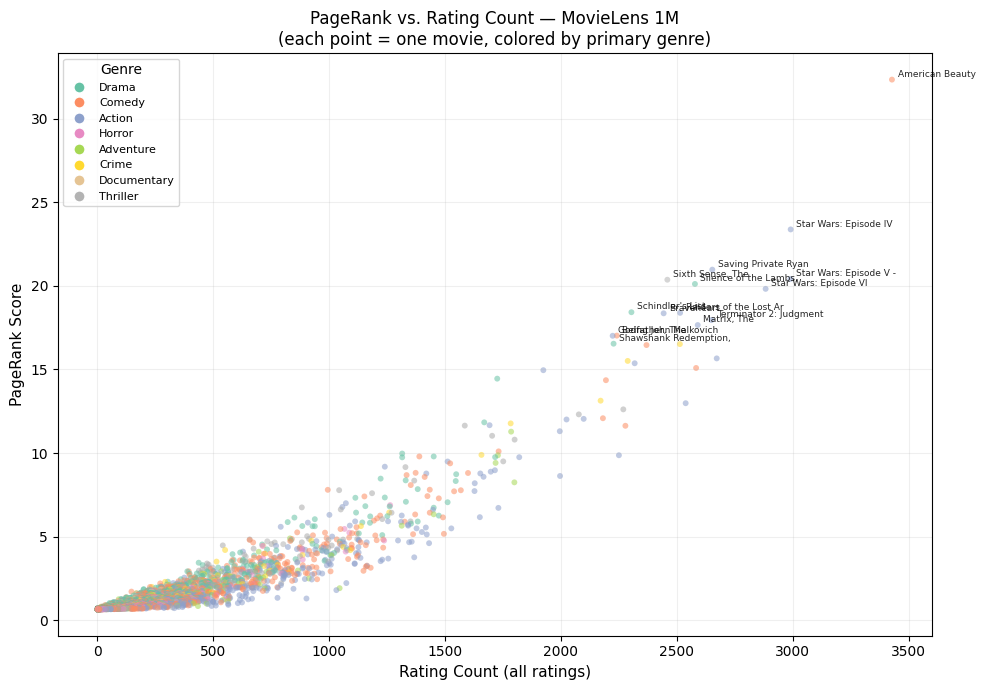

Saved: pagerank_vs_count.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

top_genres  = cmp_pd["primary_genre"].value_counts().head(8).index.tolist()
palette     = plt.cm.Set2.colors
genre_color = {g: palette[i] for i, g in enumerate(top_genres)}
colors      = [genre_color.get(g, "#aaaaaa") for g in cmp_pd["primary_genre"]]

ax.scatter(cmp_pd["rating_count"], cmp_pd["pagerank"],
           c=colors, alpha=0.55, s=18, linewidths=0)

# Label top 15 by PageRank
for _, row in cmp_pd.head(15).iterrows():
    label = row["title"].split("(")[0].strip()[:22]
    ax.annotate(label, (row["rating_count"], row["pagerank"]),
                fontsize=6.5, alpha=0.85,
                xytext=(4, 2), textcoords="offset points")

ax.set_xlabel("Rating Count (all ratings)", fontsize=11)
ax.set_ylabel("PageRank Score", fontsize=11)
ax.set_title("PageRank vs. Rating Count — MovieLens 1M\n"
             "(each point = one movie, colored by primary genre)", fontsize=12)

legend_patches = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=c, markersize=8, label=g)
    for g, c in genre_color.items()
]
ax.legend(handles=legend_patches, title="Genre", fontsize=8, loc="upper left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("pagerank_vs_count.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pagerank_vs_count.png")

> **Observe:** Strong positive correlation overall, but the rankings diverge at the edges:
> - **Climbers** (higher PR than count rank): films that attracted enthusiastic endorsements from the most active raters — insider favorites whose reputation exceeds their raw viewership.
> - **Droppers** (lower PR than count rank): widely-seen mainstream films, but many raters gave them 3 stars rather than 4-5, so the high-rating edge count is lower relative to total views.
>
> This is exactly the "links are votes, but not all votes are equal" intuition from PageRank theory.

## Task 5 — Visualize the Graph

NetworkX cannot draw 10,000 nodes clearly. We extract a **subgraph**:
- The **25 movies** with highest PageRank
- **Users** who gave >= 4 stars to at least **3 of those top-25 movies**

This gives us the dense endorsement core around the most central films.

In [ ]:
top25     = cmp_pd.head(25)[["movieId", "title", "primary_genre", "pagerank"]].copy()
top25_ids = set(top25["movieId"].tolist())

# High-rating edges to those top-25 movies
sub_edges = (
    ratings
    .filter(F.col("rating") >= 4.0)
    .filter(F.col("movieId").isin(list(top25_ids)))
    .select("userId", "movieId", "rating")
    .toPandas()
)

# Keep only users who endorsed at least 3 of the top-25 movies
movies_per_user = sub_edges.groupby("userId")["movieId"].nunique()
keep_users      = set(movies_per_user[movies_per_user >= 3].index)
sub_edges       = sub_edges[sub_edges["userId"].isin(keep_users)]

print(f"Subgraph: {len(top25)} movies, {len(keep_users):,} users, {len(sub_edges):,} edges")

Subgraph: 25 movies, 5,107 users, 49,744 edges


NetworkX graph: 5,132 nodes, 49,744 edges


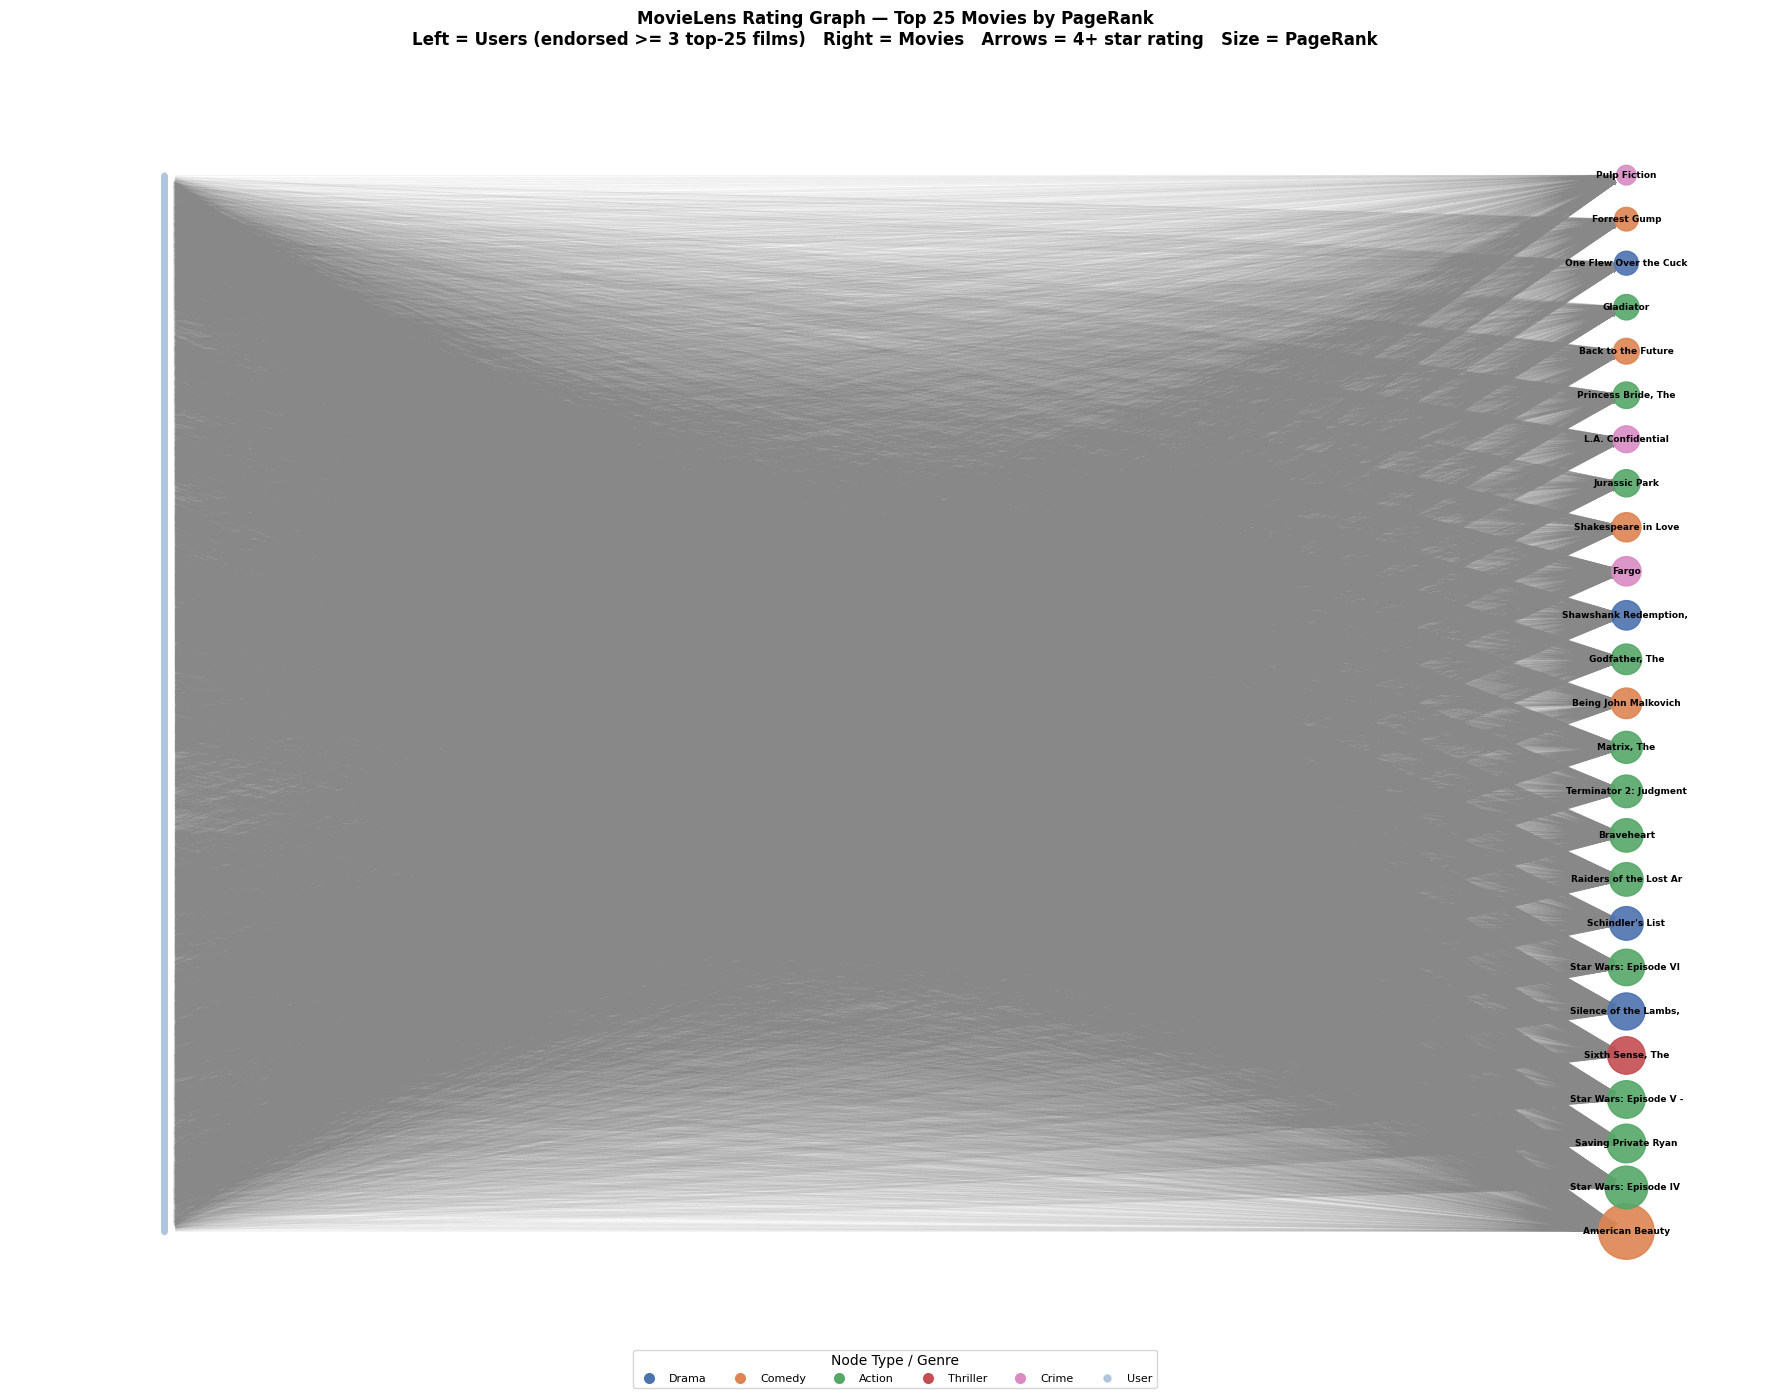

Saved: rating_graph.png


In [ ]:
G = nx.DiGraph()

# Movie nodes
for _, row in top25.iterrows():
    G.add_node(f"m_{row['movieId']}",
               node_type="movie",
               label=row["title"].split("(")[0].strip()[:22],
               genre=row["primary_genre"],
               pagerank=float(row["pagerank"]))

# User nodes + directed edges
for _, row in sub_edges.iterrows():
    uid = f"u_{int(row['userId'])}"
    mid = f"m_{int(row['movieId'])}"
    if uid not in G:
        G.add_node(uid, node_type="user", label="", genre="user", pagerank=0.0)
    G.add_edge(uid, mid, weight=float(row["rating"]))

print(f"NetworkX graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Separate node lists
movie_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "movie"]
user_nodes  = [n for n, d in G.nodes(data=True) if d["node_type"] == "user"]

# Bipartite layout: movies right, users left
pos = {}
for i, n in enumerate(movie_nodes):
    pos[n] = (1.0, i / max(len(movie_nodes) - 1, 1))
for i, n in enumerate(user_nodes):
    pos[n] = (0.0, i / max(len(user_nodes) - 1, 1))

# Genre colors
genre_colors = {
    "Drama": "#4C72B0",     "Comedy": "#DD8452",
    "Action": "#55A868",    "Thriller": "#C44E52",
    "Romance": "#8172B2",   "Adventure": "#937860",
    "Crime": "#DA8BC3",     "Sci-Fi": "#8C8C8C",
    "Horror": "#CCB974",    "Animation": "#64B5CD",
}
movie_colors = [genre_colors.get(G.nodes[n]["genre"], "#aaaaaa") for n in movie_nodes]

# Node sizes scaled by PageRank
pr_vals  = np.array([G.nodes[n]["pagerank"] for n in movie_nodes])
pr_range = pr_vals.max() - pr_vals.min() + 1e-9
m_sizes  = (200 + 1400 * (pr_vals - pr_vals.min()) / pr_range).tolist()

fig, ax = plt.subplots(figsize=(18, 14))

nx.draw_networkx_edges(
    G, pos, ax=ax, alpha=0.05, edge_color="#888888",
    arrows=True, arrowsize=4, width=0.5
)
nx.draw_networkx_nodes(
    G, pos, nodelist=user_nodes, ax=ax,
    node_color="#B0C4DE", node_size=12, alpha=0.45
)
nx.draw_networkx_nodes(
    G, pos, nodelist=movie_nodes, ax=ax,
    node_color=movie_colors, node_size=m_sizes, alpha=0.9
)
nx.draw_networkx_labels(
    G, pos, ax=ax,
    labels={n: G.nodes[n]["label"] for n in movie_nodes},
    font_size=6.5, font_weight="bold"
)

handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=c, markersize=9, label=g)
    for g, c in genre_colors.items()
    if any(G.nodes[n]["genre"] == g for n in movie_nodes)
]
handles.append(plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor="#B0C4DE", markersize=7, label="User"))
ax.legend(handles=handles, title="Node Type / Genre",
          loc="lower center", bbox_to_anchor=(0.5, -0.04),
          ncol=6, fontsize=8)

ax.set_title(
    "MovieLens Rating Graph — Top 25 Movies by PageRank\n"
    "Left = Users (endorsed >= 3 top-25 films)   Right = Movies   "
    "Arrows = 4+ star rating   Size = PageRank",
    fontsize=12, fontweight="bold", pad=14
)
ax.axis("off")
plt.tight_layout()
plt.savefig("rating_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rating_graph.png")

> **Observe:**
> - Movies on the right are **sized by PageRank** — the largest circles are the most central films in the endorsement network.
> - Users on the left fan out to whichever top-25 movies they endorsed.
> - Dense fan-in to the same movie from many users confirms its high in-degree and high PageRank.
> - Colors reveal whether any genre dominates the PageRank top 25.

## Task 6 (Bonus) — HITS from Scratch

**HITS** assigns two scores per node:
- **Hub** — a user has high hub score if they consistently endorse high-authority movies
- **Authority** — a movie has high authority if it is endorsed by high-hub users

Both scores reinforce each other through power iteration.

We implement HITS in **NumPy with a sparse matrix** rather than Spark DataFrames.
Reason: 30 Spark iterations accumulate query-plan lineage and become very slow.
NumPy on the same data (~500K edges) converges in seconds.

In [ ]:
# Collect high-rating edges to pandas
hits_edges = (
    ratings
    .filter(F.col("rating") >= 4.0)
    .select("userId", "movieId")
    .toPandas()
)

# Build integer indices
user_ids  = sorted(hits_edges["userId"].unique())
movie_ids = sorted(hits_edges["movieId"].unique())
u_idx     = {uid: i for i, uid in enumerate(user_ids)}
m_idx     = {mid: i for i, mid in enumerate(movie_ids)}

print(f"HITS graph: {len(user_ids):,} users, {len(movie_ids):,} movies, {len(hits_edges):,} edges")

HITS graph: 6,038 users, 3,533 movies, 575,281 edges


In [ ]:
# Build sparse adjacency matrix A: rows = users, cols = movies
# A[i, j] = 1 if user i rated movie j with >= 4 stars
rows = [u_idx[u] for u in hits_edges["userId"]]
cols = [m_idx[m] for m in hits_edges["movieId"]]
A    = csr_matrix(
    (np.ones(len(rows), dtype=np.float32), (rows, cols)),
    shape=(len(user_ids), len(movie_ids))
)
At = A.T   # movies x users

# HITS power iteration
HITS_ITER = 30
hub  = np.ones(len(user_ids),  dtype=np.float64)
auth = np.ones(len(movie_ids), dtype=np.float64)

for it in range(HITS_ITER):
    new_auth = At.dot(hub)
    new_auth /= np.linalg.norm(new_auth)     # L2 normalize

    new_hub = A.dot(new_auth)
    new_hub /= np.linalg.norm(new_hub)

    delta    = np.linalg.norm(new_auth - auth) + np.linalg.norm(new_hub - hub)
    auth, hub = new_auth, new_hub

    if (it + 1) % 10 == 0:
        print(f"  Iteration {it+1:2d} — delta {delta:.8f}")

print("HITS complete.")

  Iteration 10 — delta 0.00000001
  Iteration 20 — delta 0.00000000
  Iteration 30 — delta 0.00000000
HITS complete.


In [ ]:
# Top movies by HITS authority
movies_pd   = movies.select("movieId", "title", "primary_genre").toPandas()
auth_pd     = pd.DataFrame({"movieId": movie_ids, "authority": auth})
auth_merged = auth_pd.merge(movies_pd, on="movieId").sort_values("authority", ascending=False)

print("Top 20 movies by HITS Authority:")
print(auth_merged[["title", "primary_genre", "authority"]].head(20).to_string(index=False))

# Top users by hub
hub_pd = pd.DataFrame({"userId": user_ids, "hub": hub}).sort_values("hub", ascending=False)
print("\nTop 10 users by HITS Hub:")
print("(High hub = consistently endorsed the most authoritative movies)")
print(hub_pd.head(10).to_string(index=False))

Top 20 movies by HITS Authority:
                                                title primary_genre  authority
            Star Wars: Episode IV - A New Hope (1977)        Action   0.110858
Star Wars: Episode V - The Empire Strikes Back (1980)        Action   0.110270
                               American Beauty (1999)        Comedy   0.104999
                       Raiders of the Lost Ark (1981)        Action   0.102902
                     Silence of the Lambs, The (1991)         Drama   0.097842
                                   Matrix, The (1999)        Action   0.095121
                           Saving Private Ryan (1998)        Action   0.094646
                                         Fargo (1996)         Crime   0.093334
                     Shawshank Redemption, The (1994)         Drama   0.091847
                              Sixth Sense, The (1999)      Thriller   0.090209
                                Godfather, The (1972)        Action   0.089638
    Star Wars: Epis

In [ ]:
# Compare HITS authority vs PageRank — top-20 rank by each
auth_merged["hits_rank"] = auth_merged["authority"].rank(ascending=False).astype(int)
auth_top = auth_merged[["movieId", "title", "hits_rank"]].copy()

pr_top = cmp_pd[["movieId", "title", "pr_rank"]].copy()
pr_top["movieId"] = pr_top["movieId"].astype(int)

compare_hits_pr = pd.merge(
    auth_top, pr_top, on=["movieId", "title"], how="outer"
).sort_values("hits_rank")

print("HITS Authority vs PageRank — Top 20 by HITS:")
print(compare_hits_pr[["title", "hits_rank", "pr_rank"]].head(20).to_string(index=False))
print("\nWhere both ranks agree: that film is central by any link-analysis measure.")
print("Where they diverge: HITS and PageRank are capturing different graph structure.")

HITS Authority vs PageRank — Top 20 by HITS:
                                                title  hits_rank  pr_rank
            Star Wars: Episode IV - A New Hope (1977)        1.0        2
Star Wars: Episode V - The Empire Strikes Back (1980)        2.0        4
                               American Beauty (1999)        3.0        1
                       Raiders of the Lost Ark (1981)        4.0        9
                     Silence of the Lambs, The (1991)        5.0        6
                                   Matrix, The (1999)        6.0       12
                           Saving Private Ryan (1998)        7.0        3
                                         Fargo (1996)        8.0       16
                     Shawshank Redemption, The (1994)        9.0       15
                              Sixth Sense, The (1999)       10.0        5
                                Godfather, The (1972)       11.0       14
    Star Wars: Episode VI - Return of the Jedi (1983)       12.0   

## Summary

| Task | What we did | Key finding |
|---|---|---|
| 1 | Bipartite graph — users + movies, rating >= 4 edges | ~10K vertices, ~500K directed edges |
| 2 | In-degree distribution | Power law — a few films dominate |
| 3 | PageRank via GraphFrames | Top movies = endorsed by the most active raters |
| 4 | PR vs. rating count | Correlated, but insider favorites climb vs. mainstream hits |
| 5 | NetworkX bipartite visualization | Dense fan-in visible around high-PR movies |
| 6 | HITS in NumPy (bonus) | Authorities match top PR movies; hubs = eclectic power-raters |

**Connecting to the handout:** Random surfer (PageRank), power-law degree distribution,
dead ends handled by damping, and the HITS hub/authority duality — all appear here on real data.